# Regresión Lineal

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
x = np.linspace(1,200,500)
b0 = 90
b1 = 4.67
y = b0 + b1*x + np.random.normal(0, 35,500)


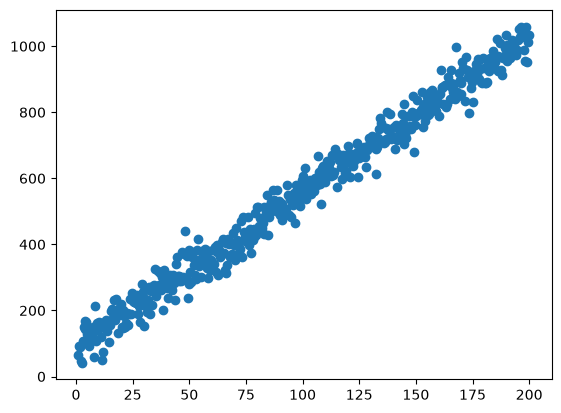

In [3]:
plt.scatter(x,y)

### Creación de un DataFrame con datos simulados.

In [4]:
df = pd.DataFrame({'gasto_publicidad':x,
                   'ventas':y})
df

,gasto_publicidad,ventas
0,1.000000,66.434892
1,1.398798,91.201356
2,1.797595,89.683156
3,2.196393,46.254718
4,2.595190,42.149605
...,...,...
495,198.404810,1059.255949
496,198.803607,1033.334864
497,199.202405,951.001611
498,199.601202,1013.793104


### Hallar el efecto que tiene el gasto de publicidad sobre las ventas

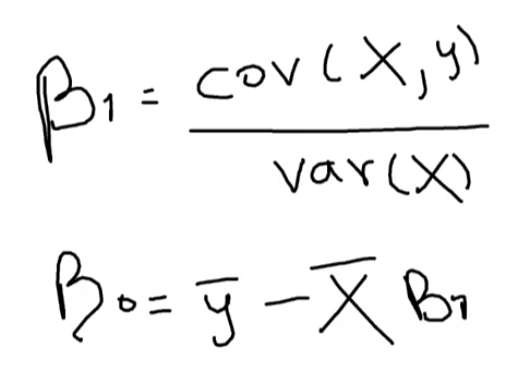

Esta formula permite hallar el efecto que tiene el gasto de publicidad sobre las ventas. Es importante hallar B1 y B0 para generar la formula de la recta.

In [5]:
#Hallamos la covarianza entre x y y
matrix = np.cov(df["gasto_publicidad"], df["ventas"])
print(matrix)

[[ 3319.95002028 15572.23890766]
 [15572.23890766 74300.20491883]]


Como resultado tenemos la matriz de varianza y covarianza

In [6]:
#varianza de gasto en publicidad var(x)
var_x =matrix[0][0]

In [7]:
#Covarianza entre gasto en publicidad y ventas cov(x,y)
cov_xy = matrix[0][1]

In [8]:
Beta1 = cov_xy/var_x
Beta1

np.float64(4.690504017389687)

In [9]:
Beta0 =df['ventas'].mean() - df["gasto_publicidad"].mean()*Beta1
Beta0

np.float64(89.43496435805088)

* Como se puede observar se ha hallado el Beta0 y Beta1, que es aproximadamente0 y b1 definidos inicialmente para graficar los datos

In [10]:
import statsmodels.formula.api as smf

In [11]:
print(smf.ols(formula='ventas ~ gasto_publicidad', data=df).fit().summary())

                            OLS Regression Results                            
Dep. Variable:                 ventas   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 2.890e+04
Date:                Fri, 07 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:39:48   Log-Likelihood:                -2493.4
No. Observations:                 500   AIC:                             4991.
Df Residuals:                     498   BIC:                             4999.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           89.4350      3.195  

* Otra forma de halla Beta0 y Beta1 es usando ols de la libreria statsmodels.
* Y como podemos observar en la columna coef tenemos a Intercept 88.8 que vendria a ser Beta0
* Y tenemos a gasto_publicidad 4.69 que vendria a ser Beta1.
evidentemente coincide con lo que hallamos de manera manual anteriormente

### Respuesta: **El  efecto que tiene la publicidad sobre las ventas es de 4.7**

### Interpretación: **Por cada dolar mas que se invierta en publicidad, las ventas aumentan en promedio en 4.7 dolares**